# Pipelines - Revamped Version


ce notebook sert pour tester le backend des pipelines

# Initialisation

In [1]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


## Imports Librairies

In [2]:
import os
import sys
from tqdm import tqdm
import glob
import numpy as np
from PIL import Image
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns




"""import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
"""



'import warnings\nfrom sklearn.exceptions import ConvergenceWarning\nwarnings.filterwarnings("ignore", category=ConvergenceWarning)\n'

## Ajouter le répertoire racine du projet au chemin Python ( à remplacer par toml)

In [3]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

## Imports Features et Transformateurs

In [4]:
from src.features.Pipelines.Transformateurs.image_augmentation import *
from src.features.Pipelines.Transformateurs.image_features import *
from src.features.Pipelines.Transformateurs.image_loaders import *
from src.features.Pipelines.Transformateurs.image_preprocessing import *
from src.features.Pipelines.Transformateurs.utilities import *
from src.features.Pipelines.loading_pipelines import *

## Checkup Transformateurs (Optionnel)

In [5]:
# Vérification que tous les transformateurs sont importés correctement
print("✅ Transformateurs importés avec succès:")
transformers = [
    ImageLoader, ImageResizer, ImageNormalizer, ImageMasker, ImageFlattener,
    ImageBinarizer, ImageAugmenter, ImageRandomCropper, ImageHistogram,
    ImagePCA, ImageStandardScaler, VisualizeTransformer, SaveTransformer
]

for transformer in transformers:
    print(f"  - {transformer.__name__}")

print(f"\n📁 Chemin du projet ajouté: {project_root}")
print(f"📂 Répertoire de travail actuel: {os.getcwd()}")

✅ Transformateurs importés avec succès:
  - ImageLoader
  - ImageResizer
  - ImageNormalizer
  - ImageMasker
  - ImageFlattener
  - ImageBinarizer
  - ImageAugmenter
  - ImageRandomCropper
  - ImageHistogram
  - ImagePCA
  - ImageStandardScaler
  - VisualizeTransformer
  - SaveTransformer

📁 Chemin du projet ajouté: c:\Users\Léna\Documents\A_Repos\Data_Pipeline
📂 Répertoire de travail actuel: c:\Users\Léna\Documents\A_Repos\Data_Pipeline\src\notebooks


## Configs

### Variables Environnement

In [6]:
root_dir = '../../data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/'

# Main

## Chargement Paths

In [7]:
X, masks, y = load_paths_data_raw(root_dir)

In [8]:
print(f"Nombre d'images: {len(X)}")
print(f"Labels uniques: {set(y)}")

Nombre d'images: 21165
Labels uniques: {'viral pneumonia', 'lung_opacity', 'covid', 'normal'}


## Split des jeux de données

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 16932, Test size: 4233


## Chargement des pipelines disponibles

In [10]:

# Chargement du registry des pipelines
registry_config = load_pipeline_config(os.path.join(project_root, "src/features/Pipelines/Configs_Pipelines/pipeline_config.json"))
print("Pipelines disponibles:")
print("=" * 50)

# Organiser par catégorie
categories = {}
for name, info in registry_config.items():
    # Ignorer les métadonnées
    if name in ["description"]:
        continue
    
    if isinstance(info, dict) and "category" in info:
        category = info.get("category", "other")
        if category not in categories:
            categories[category] = []
        categories[category].append((name, info))

# Afficher par catégorie
for category, pipelines in sorted(categories.items()):
    print(f"\nCatégorie: {category.upper()}\n")
    for name, info in pipelines:
        status = "(par défaut)" if name == "default" else ""
        print(f"  {name}: {info['description']} {status}")
        print(f"     Fichier: {info['file']}\n")

Pipelines disponibles:

Catégorie: COMPOSITE

  composite: Exemple de pipeline composite avec visualisation 
     Fichier: ../../src/features/Pipelines/Configs_Pipelines/pipeline_composite_example.json

  composite_no_viz: Pipeline composite sans visualisation (plus rapide) 
     Fichier: ../../src/features/Pipelines/Configs_Pipelines/pipeline_composite_no_viz.json


Catégorie: DATA_PROCESSING

  default: Pipeline simple et rapide (par défaut)
     Fichier: ../../src/features/Pipelines/Configs_Pipelines/pipeline_simple.json

  simple: Pipeline simple et rapide 
     Fichier: ../../src/features/Pipelines/Configs_Pipelines/pipeline_simple.json

  augmented: Pipeline avec augmentation et masquage 
     Fichier: ../../src/features/Pipelines/Configs_Pipelines/pipeline_augmented.json


Catégorie: FEATURE_ENGINEERING

  feature_engineering: Pipeline avec feature engineering avancé 
     Fichier: ../../src/features/Pipelines/Configs_Pipelines/pipeline_feature_engineering.json



## Séléction Pipeline

In [ ]:
# Chargement du pipeline par défaut
default_pipeline_name = "default"  # Le pipeline par défaut est maintenant appelé "default"
default_config = load_pipeline_config(registry_config[default_pipeline_name]["file"])
pipeline = create_pipeline_from_config(default_config, masks)

print(f"\nPipeline par défaut chargé:\n  {default_config['name']}")
print(f"Description:\n  {default_config['description']}")
print(f"Nombre d'étapes:\n  {len(pipeline.steps)}")

for step_name, step in pipeline.steps:
    print(f"  - Étape: {step_name} | Type: {type(step).__name__}")


Pipeline par défaut chargé: pipeline_simple
Description: Pipeline simple pour classification rapide
Nombre d'étapes: 5
  - Étape: img_loader | Type: ImageLoader
  - Étape: img_resizer | Type: ImageResizer
  - Étape: img_normalizer | Type: ImageNormalizer
  - Étape: img_flatten | Type: ImageFlattener
  - Étape: clf | Type: LogisticRegression


## Training Pipeline

In [12]:
# Entraînement du pipeline composite
pipeline.fit(X_train, y_train)


Chargement de 16932 images...


Images: 100%|██████████| 16932/16932 [00:18<00:00, 898.04it/s]


Chargement terminé.

[Pipeline] ........ (step 1 of 5) Processing img_loader, total=  18.9s

Redimensionnement de 16932 images en [256, 256] ...


Redimensionnement: 100%|██████████| 16932/16932 [00:08<00:00, 1903.42it/s]


Redimensionnement terminé.

[Pipeline] ....... (step 2 of 5) Processing img_resizer, total=   9.3s

Normalisation de 16932 images ...
Normalisation terminée.

[Pipeline] .... (step 3 of 5) Processing img_normalizer, total=   3.2s

Aplatissement de 16932 images ...


Aplatissement: 100%|██████████| 16932/16932 [00:01<00:00, 10630.75it/s]


Aplatissement terminé.

[Pipeline] ....... (step 4 of 5) Processing img_flatten, total=   3.2s
[Pipeline] ............... (step 5 of 5) Processing clf, total= 3.8min


c:\Users\Léna\Documents\A_Repos\Data_Pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  3.7min finished


,steps,"[('img_loader', ...), ('img_resizer', ...), ...]"
,transform_input,None
,memory,None
,verbose,True
,img_size,"(128, ...)"
,img_size,"[256, 256]"
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


## Prédiction Pipeline

In [ ]:
# Prédiction
y_pred = pipeline.predict(X_test)


Chargement de 4233 images...


Images: 100%|██████████| 4233/4233 [00:04<00:00, 879.32it/s]


Chargement terminé.


Redimensionnement de 4233 images en [256, 256] ...


Redimensionnement: 100%|██████████| 4233/4233 [00:02<00:00, 1904.41it/s]


Redimensionnement terminé.


Normalisation de 4233 images ...
Normalisation terminée.


Aplatissement de 4233 images ...


Aplatissement: 100%|██████████| 4233/4233 [00:00<00:00, 10813.99it/s]


Aplatissement terminé.



## Matrice De Confusion

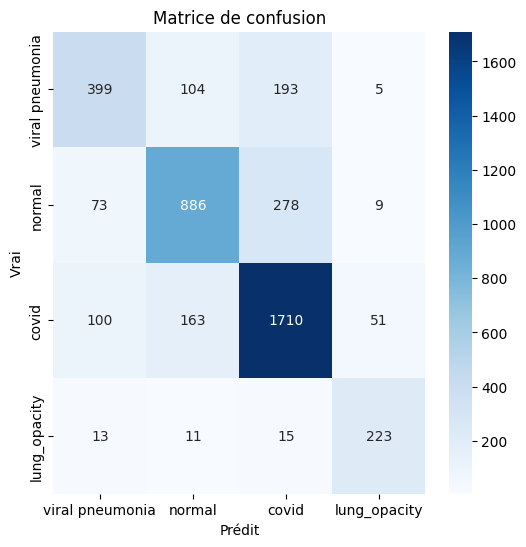

In [14]:
# Matrice de confusion visuelle
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion')
plt.show()



## Quelques exemples d'images (Vrai vs. Prédit)

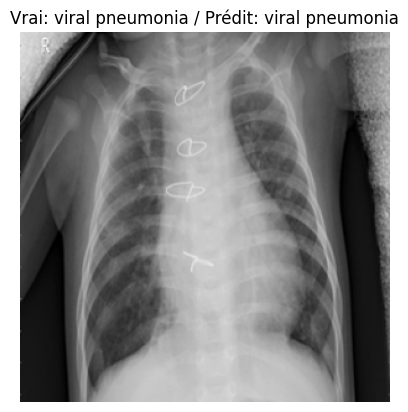

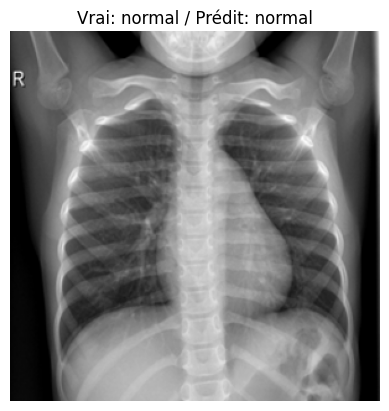

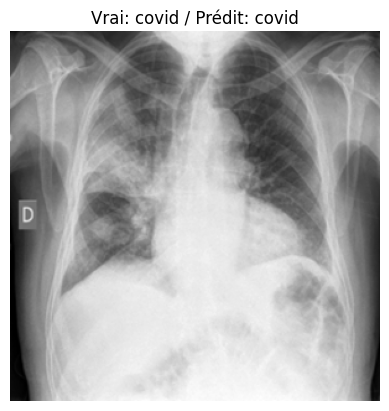

In [15]:
# Afficher quelques images test avec prédiction et vrai label
nbr_images = 3
for i in range(nbr_images):
    img = Image.open(X_test[i])
    plt.imshow(img, cmap='gray')
    plt.title(f"Vrai: {y_test[i]} / Prédit: {y_pred[i]}")
    plt.axis('off')
    plt.show()